In [1]:
import pandas as pd
X_scaled = pd.read_csv("../data/data_full_scaled.csv")

# Uticaj title atributa na rezultate klasterovanja

Naziv pozicije predstavlja jedan od najinformativnijih atributa u skupu podataka. Kako je title transformisan pomocu TF-IDF i SVD tehnika, postoji mogucnost da znacajno utice na formiranje klastera.

Cilj ove analize je poredjenje rezultata K-Means algoritma sa i bez ukljucenih `title` atributa kako bi se procenio njihov uticaj na kvalitet i interpretabilnost dobijenih segmenata.

In [2]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

In [3]:
title_cols = [col for col in X_scaled.columns if col.startswith("title_")]

len(title_cols)

200

In [4]:
X_no_title = X_scaled.drop(columns=title_cols)

X_no_title.shape

(123849, 225)

In [5]:
import numpy as np

np.random.seed(42)

sample_idx = np.random.choice(
    X_no_title.shape[0],
    size=10000,
    replace=False
)

S obzirom da su prethodni algoritmi klasterovanja davali najbolje performanse za veoma mali broj PCA komponenti, i ovaj model se obucava za k od 3 do 10.

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results_no_title = []

for n_components in [3, 4, 5, 6, 7, 8, 9, 10]:

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_no_title)

    X_sample = X_pca[sample_idx]

    for k in range(2, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X_sample)

        score = silhouette_score(X_sample, labels)

        results_no_title.append({
            "n_components": n_components,
            "k": k,
            "silhouette_score": score
        })

results_no_title = pd.DataFrame(results_no_title)

results_no_title.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)

,n_components,k,silhouette_score
1,3,3,0.409478
0,3,2,0.404585
10,4,3,0.374128
9,4,2,0.373123
18,5,2,0.349002
19,5,3,0.347188
27,6,2,0.330142
28,6,3,0.326998
4,3,6,0.318165
36,7,2,0.312931


In [10]:
best_no_title = results_no_title.sort_values(by="silhouette_score", ascending=False).iloc[0]

best_no_title

n_components        3.000000
k                   3.000000
silhouette_score    0.409478
Name: 1, dtype: float64

In [11]:
best_n_components = int(best_no_title["n_components"])
best_k = int(best_no_title["k"])

pca_no_title_best = PCA(
    n_components=best_n_components,
    random_state=42
)

X_no_title_pca_best = pca_no_title_best.fit_transform(X_no_title)

kmeans_no_title_best = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels_kmeans_no_title = kmeans_no_title_best.fit_predict(X_no_title_pca_best)

pd.Series(labels_kmeans_no_title).value_counts(normalize=True) * 100

2    54.540610
0    34.110086
1    11.349304
Name: proportion, dtype: float64

In [12]:
pd.Series(labels_kmeans_no_title).to_csv(
    "../models/kmeans_no_title_labels.csv",
    index=False
)

In [13]:
kmeans_labels = pd.read_csv(
    "../models/kmeans_labels.csv"
).squeeze("columns")

In [15]:
comparison = pd.DataFrame({
    "Model": ["K-Means sa title", "K-Means bez title"],
    "PCA": [3, best_n_components],
    "k": [6, best_k],
    "Silhouette score": [0.336, best_no_title["silhouette_score"]]
})

comparison

,Model,PCA,k,Silhouette score
0,K-Means sa title,3,6,0.336000
1,K-Means bez title,3,3,0.409478


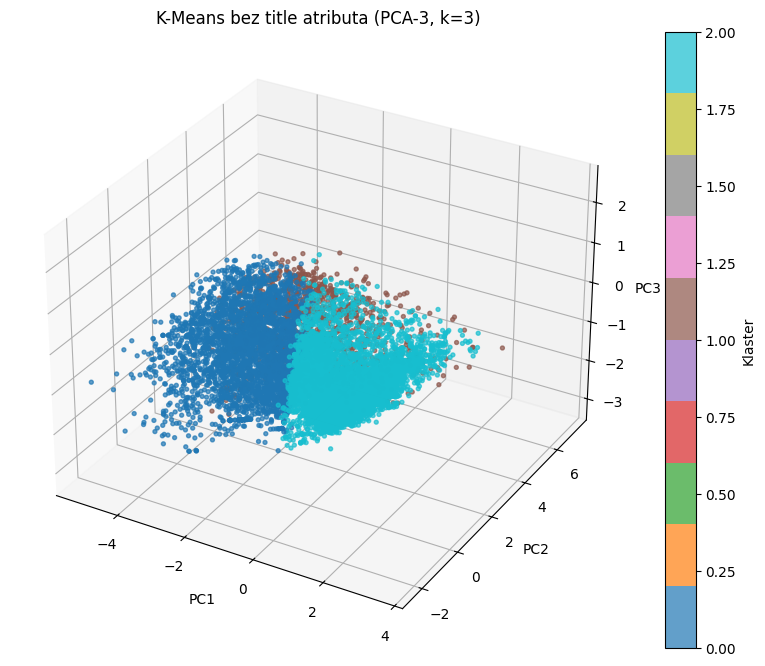

: 

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_no_title_pca_best[:, 0][sample_idx],
    X_no_title_pca_best[:, 1][sample_idx],
    X_no_title_pca_best[:, 2][sample_idx],
    c=labels_kmeans_no_title[sample_idx],
    cmap="tab10",
    s=8,
    alpha=0.7
)

ax.set_title("K-Means bez title atributa (PCA-3, k=3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, label="Klaster")
plt.show()

Uklanjanjem title atributa ostvarena je znacajno veca vrednost silhouette score metrike, dok se optimalan broj klastera smanjio sa 4 na 3. Dodatna analiza potrebna je kako bi se utvrdilo da li ukljucivanje ovog atributa doprinosi boljoj interpretabilnosti i smislenijoj segmentaciji oglasa za posao.

In [16]:
master = pd.read_csv("../data/master_clean.csv")

In [17]:
model_labels = {
    "KMeans": kmeans_labels,
    "Kmeans no title" : labels_kmeans_no_title
}

analysis_df = master.copy()

for model_name, labels in model_labels.items():
    analysis_df[f"cluster_{model_name}"] = labels

In [18]:
def categorical_profile_all_models(column):
    profiles = []

    for model_name in model_labels.keys():
        cluster_col = f"cluster_{model_name}"

        profile = (
            pd.crosstab(
                analysis_df[cluster_col],
                analysis_df[column],
                normalize="index"
            )
            .mul(100)
            .round(2)
        )

        profile["model"] = model_name
        profile["cluster"] = profile.index
        profiles.append(profile.reset_index(drop=True))

    return pd.concat(profiles, ignore_index=True)

In [23]:
from matplotlib import pyplot as plt
def plot_categorical_profile_all_models(column):

    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 8)
    )

    axes = axes.flatten()

    for ax, model_name in zip(axes, model_labels.keys()):

        cluster_col = f"cluster_{model_name}"

        profile = (
            pd.crosstab(
                analysis_df[cluster_col],
                analysis_df[column],
                normalize="index"
            )
            .mul(100)
            .round(2)
        )

        profile.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            legend=False
        )

        ax.set_title(model_name)
        ax.set_xlabel("Klaster")
        ax.set_ylabel("%")
        ax.tick_params(axis="x", rotation=0)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title=column,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    plt.suptitle(f"{column} po klasterima", fontsize=14)

    plt.tight_layout()
    plt.show()

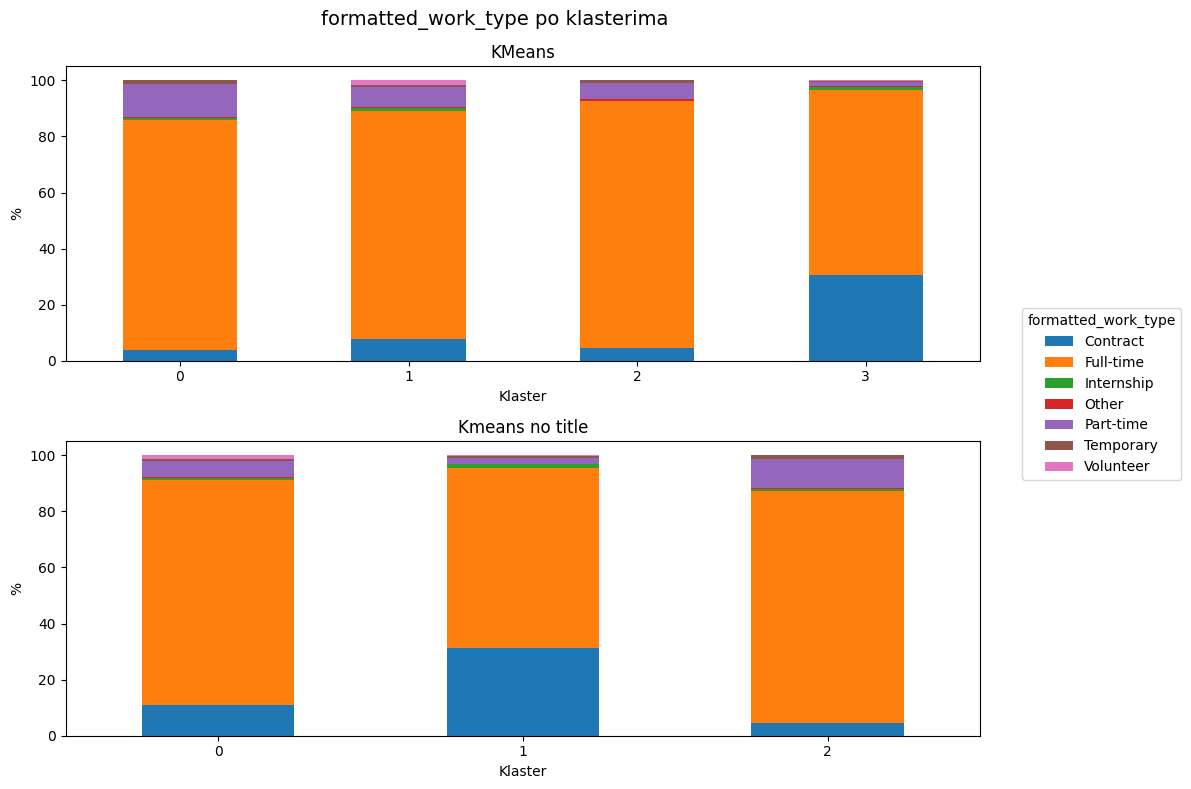

In [24]:
plot_categorical_profile_all_models("formatted_work_type")

Kod oba modela Full-time poslovi predstavljaju dominantan oblik zaposlenja. Istovremeno se u oba slucaja izdvajaju klasteri sa povecanim udelom Contract oglasa, sto ukazuje da tip zaposlenja predstavlja relevantan faktor pri formiranju klastera. Razlike izmedju modela uglavnom se ogledaju u nacinu organizacije ovih grupa, dok osnovni obrasci ostaju slicni.

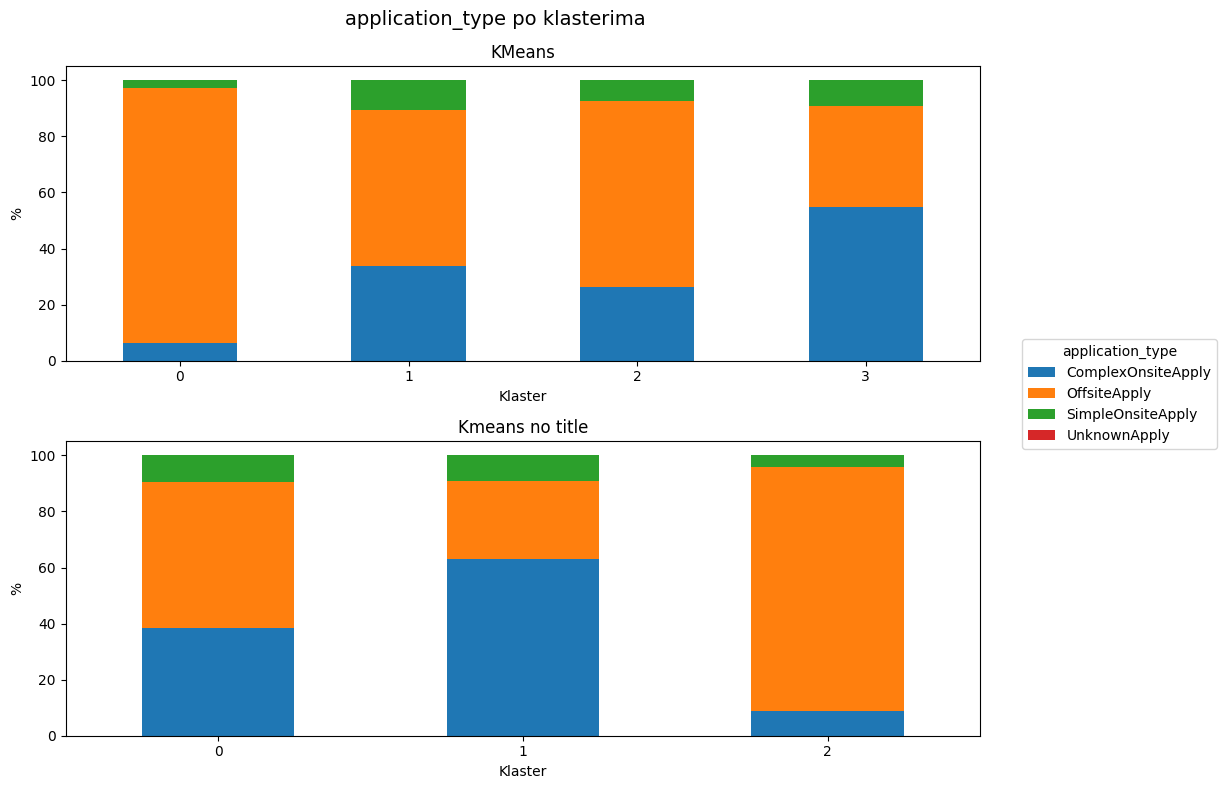

In [25]:
plot_categorical_profile_all_models("application_type")

Kod oba modela uocljive su razlike u nacinu prijavljivanja izmedju klastera. K-Means bez title atributa formira klaster sa dominantnim udelom ComplexOnsiteApply oglasa i klaster kod kog dominira OffsiteApply. Slican obrazac prisutan je i kod modela sa title atributom, gde se posebno izdvajaju klasteri 0 i 3. To ukazuje da application_type predstavlja znacajan atribut koji doprinosi formiranju klastera nezavisno od prisustva informacija o nazivu pozicije.

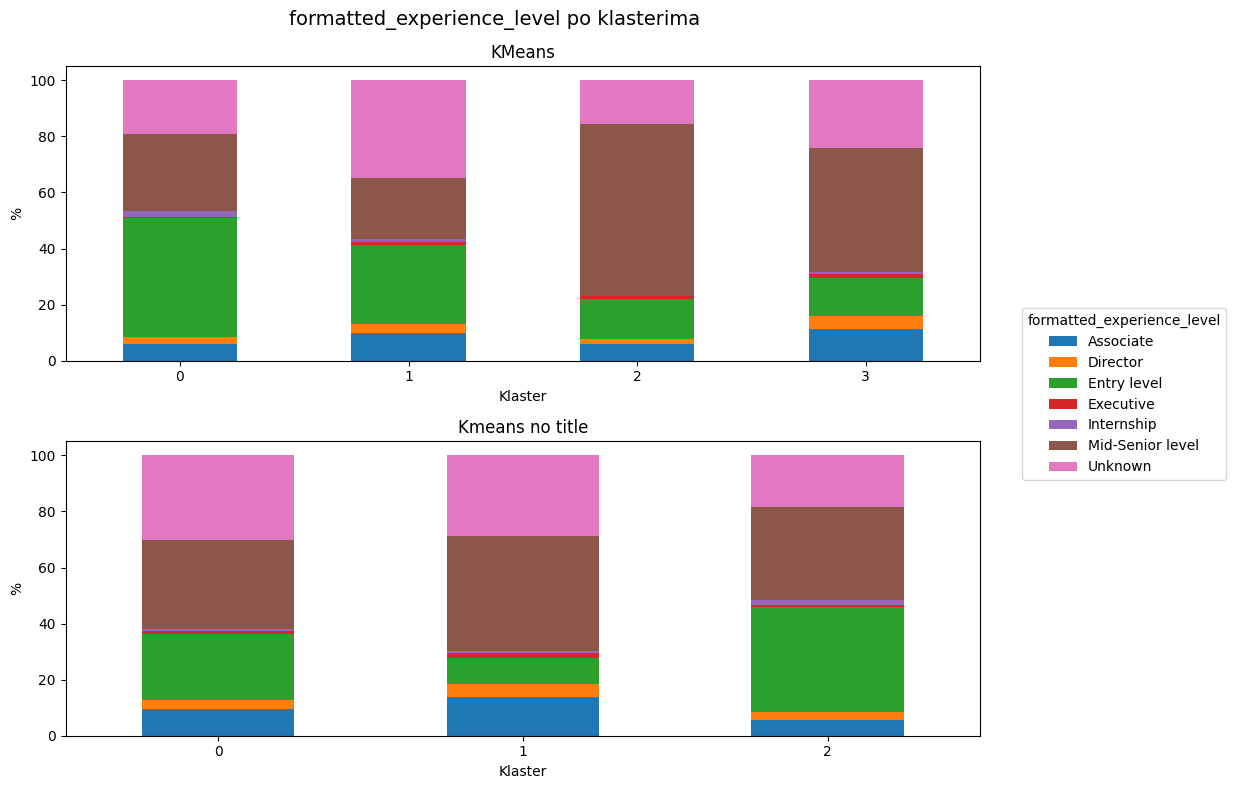

In [26]:
plot_categorical_profile_all_models("formatted_experience_level")

Kod oba modela uocavaju se razlike u zastupljenosti nivoa iskustva izmedju klastera. K-Means sa title atributom formira klaster 0 sa izrazito visokim udelom Entry level pozicija, dok je klaster 2 dominantno sastavljen od Mid-Senior level oglasa. Sa druge strane, kod modela bez title atributa razlike izmedju klastera su ravnomernije rasporedjene, pri cemu se izdvajaju klasteri sa vecim udelom Entry level i Associate pozicija. Na osnovu ovih rezultata moze se zakljuciti da oba modela prepoznaju razlike u senioritetu pozicija, ali ih organizuju na razlicit nacin.

In [27]:
def save_top_titles(labels, model_name, n=10):

    temp = master.copy()
    temp["cluster"] = labels

    with open(
        f"../results/{model_name}_top_titles.txt",
        "w",
        encoding="utf-8"
    ) as f:

        f.write(f"{model_name}\n")
        f.write("=" * 80 + "\n\n")

        for cluster in sorted(temp["cluster"].unique()):

            f.write(f"CLUSTER {cluster}\n")
            f.write("-" * 40 + "\n")

            top_titles = (
                temp[temp["cluster"] == cluster]["title"]
                .value_counts()
                .head(n)
            )

            for title, count in top_titles.items():
                f.write(f"{title}: {count}\n")

            f.write("\n")

In [28]:
save_top_titles(labels_kmeans_no_title, "KMeans no title")

### Analiza dominantnih naziva pozicija

Analiza dominantnih naziva pozicija otkriva znacajne razlike izmedju modela koji koristi title atribut i modela kod kog je ovaj atribut uklonjen. Iako model bez title atributa ostvaruje vecu vrednost silhouette score metrike, struktura dobijenih klastera ukazuje da se u okviru istih grupa pojavljuje veliki broj medjusobno razlicitih zanimanja.

Kod modela bez title atributa prvi klaster istovremeno obuhvata menadzerske pozicije (Sales Manager, Project Manager), administrativne poslove (Executive Assistant, Administrative Assistant), finansijske strucnjake (Staff Accountant, Senior Accountant), ali i zdravstvene radnike poput Registered Nurse. Slicna situacija prisutna je i u preostalim klasterima. Drugi klaster okuplja softverske inzenjere, analiticare podataka, poslovne analiticare i administrativne pozicije, dok treci klaster sadrzi kombinaciju prodajnih, maloprodajnih, administrativnih i zdravstvenih zanimanja. Iako se mogu uociti odredjeni zajednicki obrasci, granice izmedju profesionalnih grupa nisu jasno definisane.

Sa druge strane, ukljucivanje title atributa dovodi do znatno homogenijih i intuitivnijih klastera. Klaster 0 dominantno okuplja operativne i korisnicki orijentisane poslove kao sto su Customer Service Representative, Receptionist, Patient Care Technician i Package Handler. Klaster 1 karakterisu administrativne, pravne i strucne pozicije poput Executive Assistant, Staff Accountant, Associate Attorney i Physical Therapist. Klaster 2 predstavlja veoma jasno definisanu grupu menadzerskih i rukovodecih pozicija, ukljucujuci Sales Manager, Project Manager, Store Manager, Assistant Manager i Business Development Manager. Konacno, klaster 3 okuplja tehnicke i analiticke profesije kao sto su Software Engineer, Data Engineer, Data Analyst, Business Analyst i Electrical Engineer.

Ovakvi rezultati ukazuju da title atribut sadrzi veoma znacajnu informaciju o prirodi posla i omogucava formiranje klastera koji mnogo bolje odgovaraju stvarnim profesionalnim grupama na trzistu rada. Iako njegovo ukljucivanje dovodi do nize vrednosti silhouette score metrike, dobijeni klasteri su znacajno laksi za interpretaciju i pruzaju jasniji uvid u strukturu oglasa za posao. Nasuprot tome, model bez title atributa formira kompaktnije klastere sa stanovista interne evaluacije, ali oni predstavljaju sire kategorije poslova i ne omogucavaju jednako preciznu profesionalnu segmentaciju.

In [29]:
master_raw = pd.read_csv("../data/master_raw.csv")

/tmp/ipykernel_159441/1255469675.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  master_raw = pd.read_csv("../data/master_raw.csv")


### Analiza plata po klasterima

U prethodnom notebook-u koji se bavio evaluacijom modela, analiza plata koriscena je kao oblik eksterne validacije kvaliteta klasterovanja. Buduci da informacije o platama nisu koriscene tokom procesa formiranja klastera, razlike u raspodeli plata izmedju dobijenih grupa mogu predstavljati pokazatelj da model identifikuje stvarne obrasce prisutne na trzistu rada.

Kako je cilj ovog notebook-a poredjenje K-Means modela sa i bez ukljucenog title atributa, ista analiza bice ponovljena i za obe varijante modela. Na taj nacin moguce je proceniti da li klasteri dobijeni u oba slucaja izdvajaju grupe poslova sa razlicitim nivoima kompenzacije i da li ukljucivanje title atributa doprinosi boljoj segmentaciji oglasa sa aspekta plata.

In [30]:
salary_summaries = []

for model_name, labels in model_labels.items():

    temp = pd.DataFrame({
        "model": model_name,
        "cluster": labels,
        "salary": master_raw["normalized_salary"]
    })

    summary = (
        temp
        .groupby(["model", "cluster"])["salary"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )

    salary_summaries.append(summary)

salary_summary = pd.concat(salary_summaries, ignore_index=True)

salary_summary[["mean", "median", "std", "min", "max"]] = (
    salary_summary[["mean", "median", "std", "min", "max"]]
    .round(2)
)

salary_summary

,model,cluster,count,mean,median,std,min,max
0,KMeans,0,13889,196704.21,66560.00,4417363.19,1.0,362408800.0
1,KMeans,1,9854,219794.42,72083.00,6506204.31,0.0,535600000.0
2,KMeans,2,4526,129408.54,100000.00,1776932.20,0.0,119600000.0
3,KMeans,3,7804,246435.19,110000.00,5487248.19,0.0,286000000.0
4,Kmeans no title,0,12462,230527.64,80060.04,6555721.87,0.0,535600000.0
5,Kmeans no title,1,5507,204632.01,101500.00,4424404.40,0.0,286000000.0
6,Kmeans no title,2,18104,188191.46,75000.00,4030089.70,1.0,362408800.0


In [31]:
salary_median_table = salary_summary[
    ["model", "cluster", "count", "median"]
].copy()

salary_median_table["model_cluster"] = (
    salary_median_table["model"] 
    + " C" 
    + salary_median_table["cluster"].astype(str)
)

salary_median_table

,model,cluster,count,median,model_cluster
0,KMeans,0,13889,66560.00,KMeans C0
1,KMeans,1,9854,72083.00,KMeans C1
2,KMeans,2,4526,100000.00,KMeans C2
3,KMeans,3,7804,110000.00,KMeans C3
4,Kmeans no title,0,12462,80060.04,Kmeans no title C0
5,Kmeans no title,1,5507,101500.00,Kmeans no title C1
6,Kmeans no title,2,18104,75000.00,Kmeans no title C2


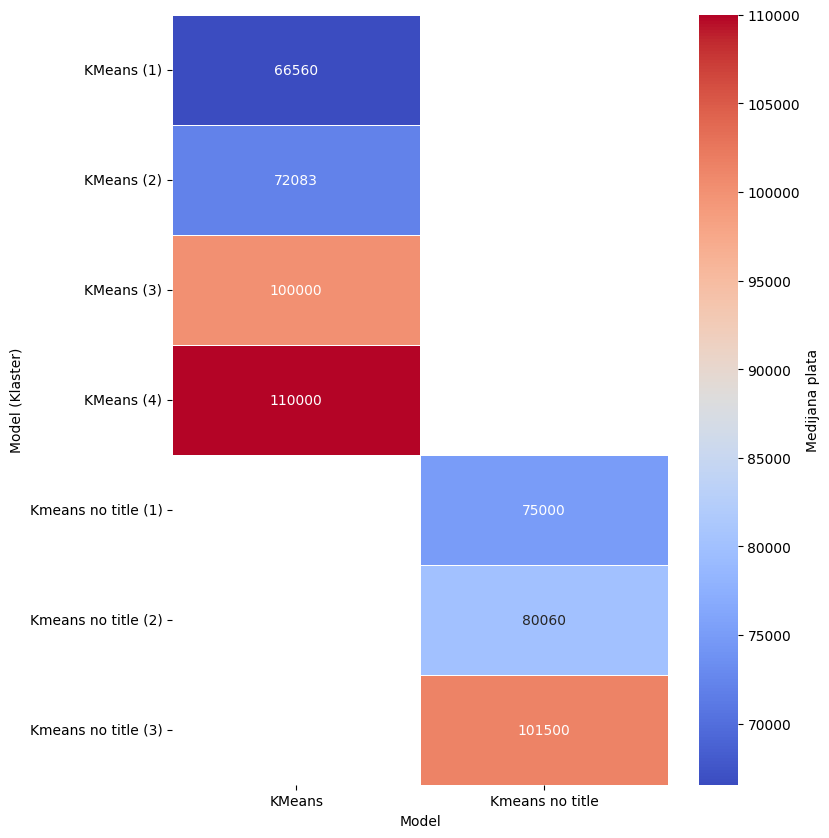

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

salary_heatmap = salary_median_table.copy()

salary_heatmap = (
    salary_heatmap
    .sort_values(
        ["model", "median"],
        ascending=[True, True]
    )
)

salary_heatmap["model_cluster"] = (
    salary_heatmap["model"]
    + " ("
    + salary_heatmap.groupby("model").cumcount().add(1).astype(str)
    + ")"
)

heatmap_data = salary_heatmap.pivot(
    index="model_cluster",
    columns="model",
    values="median"
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Medijana plata"}
)

plt.xlabel("Model")
plt.ylabel("Model (Klaster)")

plt.show()

### Zakljucak analize plata

Analiza plata dodatno potvrdjuje razlike izmedju dva pristupa klasterovanju. Iako model bez title atributa ostvaruje vecu vrednost silhouette score metrike, model koji ukljucuje title atribut formira klastere sa znatno izrazenijim razlikama u nivoima kompenzacije. Razlika izmedju najnize i najvise medijalne plate kod K-Means modela sa title atributom iznosi preko 43 hiljade dolara, dok je kod modela bez title atributa ta razlika priblizno 26 hiljada dolara.

### Konacni zakljucak

Na prvi pogled rezultati ukazuju da model bez title atributa predstavlja bolje resenje, s obzirom na vecu vrednost silhouette score metrike i jasnije granice izmedju klastera u PCA prostoru. Medjutim, detaljnija analiza dobijenih segmenata pokazuje da ovakvi klasteri nisu organizovani na nacin koji odgovara intuitivnom ljudskom razumevanju trzista rada. U okviru istih klastera pojavljuju se veoma razlicita zanimanja, a granice izmedju profesionalnih grupa ostaju nejasne uprkos dobroj internoj evaluaciji.

Sa druge strane, model koji ukljucuje title atribut formira klastere koji imaju znatno jasnije i smislenije tumacenje. Dobijene grupe odgovaraju prepoznatljivim profesionalnim kategorijama, pokazuju izrazene razlike u nivoima plata, a razlike se mogu uociti i kroz ostale analizirane karakteristike oglasa kao sto su tip zaposlenja, nacin prijavljivanja i nivo iskustva. Iako title atribut uvodi veliki broj dodatnih karakteristika i dovodi do nesto nize vrednosti silhouette score metrike, njegova informativnost se pokazala kljucnom za formiranje smislenih segmenata.

Dobijeni rezultati potvrdjuju pocetnu hipotezu da title atribut ne treba uklanjati iz procesa klasterovanja. Uprkos tome sto model bez title atributa ostvaruje bolje rezultate prema internim metrikama, model sa ukljucenim title atributom daje klastere koji bolje odrazavaju stvarnu strukturu trzista rada i omogucavaju znatno kvalitetniju interpretaciju dobijenih segmenata.